In [11]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Dirichlet
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm import tqdm
from abc import ABC, abstractmethod
import numpy as np

# =========================================
# 0) Device Setup
# =========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =========================================
# 1) Data Module for CIFAR-10
# =========================================
class CIFAR10Data:
    def __init__(self, batch_size=128, val_split=5000):
        transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                                 (0.2470, 0.2435, 0.2616)),
        ])
        dataset = datasets.CIFAR10(root='./data', train=True,
                                   download=True, transform=transform)
        train_size = len(dataset) - val_split
        train_ds, val_ds = random_split(dataset, [train_size, val_split])

        self.train_loader = DataLoader(train_ds, batch_size=batch_size,
                                       shuffle=True, num_workers=4)
        self.val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                                       shuffle=False, num_workers=4)

# =========================================
# 2) Dirichlet Sampler & STE
# =========================================
class DirichletSampler:
    def __init__(self, alpha):
        self.dist = Dirichlet(torch.tensor(alpha, dtype=torch.float,
                                           device=device))
    def sample(self):
        return self.dist.rsample().to(device)

class ReinMaxSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, logits):
        probs = F.softmax(logits, dim=-1)
        idx   = probs.argmax(dim=-1)
        one_hot = F.one_hot(idx, num_classes=logits.size(-1)).type_as(logits)
        ctx.save_for_backward(probs)
        return one_hot
    @staticmethod
    def backward(ctx, grad_output):
        (probs,) = ctx.saved_tensors
        return grad_output * probs * (1 - probs)
reinforce_max = ReinMaxSTE.apply

# =========================================
# 3) Primitives
# =========================================
def sep_conv(C, k, s, p):
    return nn.Sequential(
        nn.ReLU(inplace=False),
        nn.Conv2d(C, C, k, s, p, groups=C, bias=False),
        nn.Conv2d(C, C, 1, bias=False),
        nn.BatchNorm2d(C),
    )
def dil_conv(C, k, s, p, d):
    return nn.Sequential(
        nn.ReLU(inplace=False),
        nn.Conv2d(C, C, k, s, p, dilation=d, bias=False),
        nn.BatchNorm2d(C),
    )
def skip_connect(): return nn.Identity()
def avg_pool(C, k, s, p): return nn.AvgPool2d(k, stride=s, padding=p)

# =========================================
# 4) MixedOp & ResidualCell
# =========================================
class MixedOp(nn.Module):
    def __init__(self, C):
        super().__init__()
        self.ops = nn.ModuleList([
            sep_conv(C,3,1,1), sep_conv(C,5,1,2),
            dil_conv(C,3,1,2,2),
            nn.Sequential(nn.ReLU(inplace=False), nn.Conv2d(C,C,1,bias=False), nn.BatchNorm2d(C)),
            avg_pool(C,3,1,1), skip_connect()
        ])
    def forward(self, x, weights):
        return sum(w*op(x) for w,op in zip(weights,self.ops))

class ResidualCell(nn.Module):
    def __init__(self, C, num_nodes=4):
        super().__init__(); self.num_nodes=num_nodes
        self.pre = nn.Sequential(nn.Conv2d(C,C,1,bias=False), nn.BatchNorm2d(C), nn.ReLU(inplace=False))
        self.ops=nn.ModuleDict({f"{i}<-{j}":MixedOp(C)
                                for i in range(num_nodes+1)
                                for j in range(i+1,num_nodes+1)})
        self.post=nn.Sequential(nn.ReLU(inplace=False), nn.Conv2d(C*num_nodes,C,1,bias=False), nn.BatchNorm2d(C))
    def forward(self,s0,weights):
        states=[self.pre(s0)]
        for new in range(1,self.num_nodes+1):
            tot=0
            for idx,h in enumerate(states):
                key=f"{idx}<-{new}"
                tot+=self.ops[key](h,weights[key])
            states.append(tot)
        concat=torch.cat(states[1:],dim=1)
        return self.post(concat)+s0

# =========================================
# 5) CellArchParam
# =========================================
class CellArchParam(nn.Module):
    def __init__(self,C,num_nodes=4,num_ops=6):
        super().__init__()
        self.alphas=nn.ParameterDict({f"{i}<-{j}":nn.Parameter(1e-3*torch.randn(num_ops,device=device))
                                       for i in range(num_nodes+1)
                                       for j in range(i+1,num_nodes+1)})
    def forward(self,logits):
        return {k:F.softmax(logits[i],dim=-1)
                for i,k in enumerate(self.alphas.keys())}

# =========================================
# 6) SuperNetwork
# =========================================
class SuperNetwork(nn.Module):
    def __init__(self,C=16,num_cells=4,num_nodes=4,num_ops=6,dropout_p=0.2):
        super().__init__(); self.stem=nn.Sequential(nn.Conv2d(3,C,3,2,1,bias=False), nn.BatchNorm2d(C), nn.ReLU(inplace=False), nn.Dropout(dropout_p))
        self.cells=nn.ModuleList([nn.ModuleDict({'arch':CellArchParam(C,num_nodes,num_ops),'body':ResidualCell(C,num_nodes)}) for _ in range(num_cells)])
        self.global_pool=nn.AdaptiveAvgPool2d(1); self.cls_head=nn.Sequential(nn.Dropout(dropout_p),nn.Linear(C,10))
        self.num_blocks=sum(len(c['arch'].alphas) for c in self.cells); self.num_ops=num_ops
    def forward(self,x,arch_logits):
        out=self.stem(x);offset=0
        for cell in self.cells:
            ne=len(cell['arch'].alphas)
            sl=arch_logits[offset:offset+ne];w=cell['arch'](sl)
            out=cell['body'](out,w);offset+=ne
        gap=self.global_pool(out).view(x.size(0),-1);return self.cls_head(gap)

# =========================================
# 7) HyperNetwork
# =========================================
class HyperNetwork(nn.Module):
    def __init__(self,num_blocks,num_ops,hidden_dim=128,depth=3):
        super().__init__(); layers=[nn.Linear(2,hidden_dim)]
        for _ in range(depth-1): layers+= [nn.ReLU(inplace=False),nn.Linear(hidden_dim,hidden_dim),nn.LayerNorm(hidden_dim)]
        self.mlp=nn.Sequential(*layers); self.fc_out=nn.Linear(hidden_dim,num_blocks*num_ops)
        self.num_blocks=num_blocks; self.num_ops=num_ops
    def forward(self,lambda_vec):
        x=lambda_vec.unsqueeze(0) if lambda_vec.dim()==1 else lambda_vec
        h=self.mlp(x);out=self.fc_out(h).view(-1,self.num_blocks,self.num_ops)
        return out.squeeze(0) if lambda_vec.dim()==1 else out

# =========================================
# 8) MGDA Solver
# =========================================
def solve_mgda_weights(M,iters=50,lr=1e-1,device='cpu'):
    k=M.shape[0];alpha=torch.full((k,),1.0/k,device=device)
    for _ in range(iters):
        grad_alpha=2*M@alpha;alpha-=lr*grad_alpha
        u,_=torch.sort(alpha,descending=True);cssv=torch.cumsum(u,dim=0)-1
        n=torch.arange(1,k+1,device=device,dtype=cssv.dtype);mask=u*n>cssv
        rho=torch.nonzero(mask,as_tuple=False)[-1,0];theta=cssv[rho]/(rho.float()+1)
        alpha=torch.clamp(alpha-theta,min=0)
    return alpha

# =========================================
# 9) Architecture Updaters
# =========================================
class ArchUpdater(ABC):
    @abstractmethod
    def update(self,hypernet,supernet,val_batch,counts,max_size): pass

class MGDAArchUpdater(ArchUpdater):
    def __init__(self,opt,mgda_iters=50):self.opt, self.iters=opt, mgda_iters
    def update(self,hypernet,supernet,val_batch,counts,max_size):
        x,y=val_batch; x,y=x.to(device),y.to(device)
        lambda_vec=DirichletSampler([1.0,1.0]).sample()
        arch_logits=hypernet(lambda_vec);out=supernet(x,arch_logits)
        loss_cls=F.cross_entropy(out,y);loss_size=(reinforce_max(arch_logits)*counts).sum()/max_size
        self.opt.zero_grad()
        # per-objective grads
        grads=[]
        for loss in (loss_cls,loss_size):
            g=torch.autograd.grad(loss,hypernet.parameters(),retain_graph=True,allow_unused=True)
            flat=torch.cat([(gi if gi is not None else torch.zeros_like(p)).flatten() for gi,p in zip(g,hypernet.parameters())])
            grads.append(flat/(flat.norm()+1e-8))
        G=torch.stack(grads);M=G@G.T;alpha=solve_mgda_weights(M,self.iters,device)
        comb=alpha[0]*grads[0]+alpha[1]*grads[1]
        # scatter
        offset=0
        for p in hypernet.parameters():
            n=p.numel();p.grad=comb[offset:offset+n].view_as(p);offset+=n
        self.opt.step()

class NSGAIIArchUpdater(ArchUpdater):
    def __init__(self,opt,rays,K=10):self.opt,rays,self.K=opt,rays,K
    def update(self,hypernet,supernet,val_batch,counts,max_size):
        x,y=val_batch; x,y=x.to(device),y.to(device)
        losses,grads=[],[]
        for r in self.rays:
            hypernet.zero_grad()
            logit=hypernet(r);out=supernet(x,logit)
            lc,ls=F.cross_entropy(out,y),(reinforce_max(logit)*counts).sum()/max_size
            losses.append([lc.item(),ls.item()]);(r[0]*lc+r[1]*ls).backward()
            grads.append(torch.cat([p.grad.flatten() for p in hypernet.parameters()]))
        costs=np.array(losses)
        mask=np.ones(len(costs),dtype=bool)
        for i,c in enumerate(costs):mask[i]=not np.any((costs[mask]<c).all(axis=1))
        front_idx=np.where(mask)[0];front_losses=costs[front_idx]
        dist=np.zeros(len(front_losses))
        for m in range(2):
            order=np.argsort(front_losses[:,m]);dist[order[0]]=dist[order[-1]]=np.inf
            lo,hi=front_losses[order[0],m],front_losses[order[-1],m]
            denom=hi-lo+1e-12
            for j in range(1,len(front_losses)-1):prev,next=front_losses[order[j-1],m],front_losses[order[j+1],m];dist[order[j]]+= (next-prev)/denom
        keep=front_idx[np.argsort(-dist)[:self.K]] if len(front_idx)>self.K else front_idx
        g_avg=torch.stack([grads[i] for i in keep]).mean(dim=0)
        self.opt.zero_grad();offset=0
        for p in hypernet.parameters():n=p.numel();p.grad=g_avg[offset:offset+n].view_as(p);offset+=n
        self.opt.step()

class RandomSearchArchUpdater(ArchUpdater):
    def __init__(self,opt,sampler,num_samples=10):self.opt,self.sampler,self.num_samples=opt,sampler,num_samples;self.best_lambda=torch.tensor([1.0,0.0],device=device)
    def update(self,hypernet,supernet,val_batch,counts,max_size):
        x,y=val_batch; x,y=x.to(device),y.to(device)
        best=float('inf')
        for _ in range(self.num_samples):
            lam=self.sampler.sample();logit=hypernet(lam);out=supernet(x,logit)
            lc,ls=F.cross_entropy(out,y).item(),((reinforce_max(logit)*counts).sum()/max_size).item()
            score=lam[0]*lc+lam[1]*ls
            if score<best:best, self.best_lambda=score, lam.detach()
        # step on best lambda
        self.opt.zero_grad();logit=hypernet(self.best_lambda);loss=F.cross_entropy(supernet(x,logit),y);loss.backward();self.opt.step()

# =========================================
# 10) Trainer
# =========================================
class Trainer:
    def __init__(self,snet,hnet,opt_w,upd,data,counts,max_size):
        self.snet, self.hnet, self.opt_w, self.upd, self.data, self.counts, self.max_size = snet, hnet, opt_w, upd, data, counts, max_size
    def train(self,epochs):
        for e in range(epochs):
            val_batch=next(iter(self.data.val_loader))
            self.upd.update(self.hnet,self.snet,val_batch,self.counts,self.max_size)
            lam=getattr(self.upd,'best_lambda',torch.tensor([1.0,0.0],device=device))
            for x,y in tqdm(self.data.train_loader,desc=f"Epoch {e} W-update",leave=False):
                x,y=x.to(device),y.to(device)
                self.opt_w.zero_grad();out=self.snet(x,self.hnet(lam));loss=F.cross_entropy(out,y);loss.backward();self.opt_w.step()

# =========================================
# 11) Main
# =========================================
def main(use_nsga=False,use_rand=False):
    data=CIFAR10Data()
    snet=SuperNetwork().to(device);hnet=HyperNetwork(snet.num_blocks,snet.num_ops).to(device)
    opt_w=torch.optim.SGD(snet.parameters(),lr=0.025,momentum=0.9)
    opt_h=torch.optim.SGD(hnet.parameters(),lr=0.01,momentum=0.9)
    # compute size counts
    op_counts=[]
    for cell in snet.cells:
        for m in cell['body'].ops.values():op_counts.append([sum(p.numel() for p in op.parameters()) for op in m.ops])
    counts=torch.tensor(op_counts,device=device,dtype=torch.float)
    max_size=counts.max(dim=1).values.sum().item()
    if use_rand: upd=RandomSearchArchUpdater(opt_h,DirichletSampler([1.0,0.1]),30)
    elif use_nsga:
        thetas=np.linspace(1e-3,np.pi/2-1e-3,60)
        rays=[torch.tensor([np.cos(t),np.sin(t)],device=device,dtype=torch.float) for t in thetas]
        upd=NSGAIIArchUpdater(opt_h,rays, K=10)
    else: upd=MGDAArchUpdater(opt_h)
    Trainer(snet,hnet,opt_w,upd,data,counts,max_size).train(epochs=5)

if __name__=='__main__': main(use_nsga=False,use_rand=True)


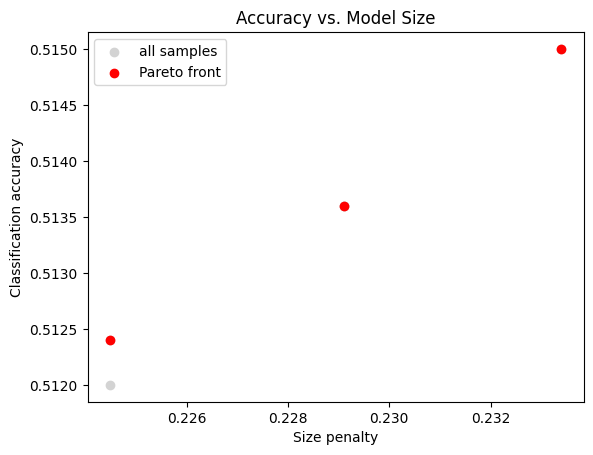

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.distributions import Dirichlet
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms
from tqdm import tqdm
from abc import ABC, abstractmethod
import numpy as np
import matplotlib.pyplot as plt

# =========================================
# 0) Device Setup
# =========================================
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

# =========================================
# 1) Data Module for CIFAR-10
# =========================================
class CIFAR10Data:
    def __init__(self, batch_size=128, val_split=5000):
        transform = transforms.Compose([
            transforms.RandomCrop(32, padding=4),
            transforms.RandomHorizontalFlip(),
            transforms.ToTensor(),
            transforms.Normalize((0.4914, 0.4822, 0.4465),
                                 (0.2470, 0.2435, 0.2616)),
        ])
        dataset = datasets.CIFAR10(root='./data', train=True,
                                   download=True, transform=transform)
        train_size = len(dataset) - val_split
        train_ds, val_ds = random_split(dataset, [train_size, val_split])

        self.train_loader = DataLoader(train_ds, batch_size=batch_size,
                                       shuffle=True, num_workers=4)
        self.val_loader   = DataLoader(val_ds,   batch_size=batch_size,
                                       shuffle=False, num_workers=4)

# =========================================
# 2) Dirichlet Sampler & STE
# =========================================
class DirichletSampler:
    def __init__(self, alpha):
        self.dist = Dirichlet(torch.tensor(alpha, dtype=torch.float, device=device))
    def sample(self):
        return self.dist.rsample().to(device)

class ReinMaxSTE(torch.autograd.Function):
    @staticmethod
    def forward(ctx, logits):
        probs = F.softmax(logits, dim=-1)
        idx   = probs.argmax(dim=-1)
        one_hot = F.one_hot(idx, num_classes=logits.size(-1)).type_as(logits)
        ctx.save_for_backward(probs)
        return one_hot
    @staticmethod
    def backward(ctx, grad_output):
        (probs,) = ctx.saved_tensors
        return grad_output * probs * (1 - probs)
reinforce_max = ReinMaxSTE.apply

# =========================================
# 3) Primitives
# =========================================
def sep_conv(C, k, s, p):
    return nn.Sequential(
        nn.ReLU(inplace=False),
        nn.Conv2d(C, C, k, s, p, groups=C, bias=False),
        nn.Conv2d(C, C, 1, bias=False),
        nn.BatchNorm2d(C),
    )
def dil_conv(C, k, s, p, d):
    return nn.Sequential(
        nn.ReLU(inplace=False),
        nn.Conv2d(C, C, k, s, p, dilation=d, bias=False),
        nn.BatchNorm2d(C),
    )
def skip_connect(): return nn.Identity()
def avg_pool(C, k, s, p): return nn.AvgPool2d(k, stride=s, padding=p)

# =========================================
# 4) MixedOp & ResidualCell
# =========================================
class MixedOp(nn.Module):
    def __init__(self, C):
        super().__init__()
        self.ops = nn.ModuleList([
            sep_conv(C,3,1,1), sep_conv(C,5,1,2),
            dil_conv(C,3,1,2,2),
            nn.Sequential(nn.ReLU(inplace=False), nn.Conv2d(C,C,1,bias=False), nn.BatchNorm2d(C)),
            avg_pool(C,3,1,1), skip_connect()
        ])
    def forward(self, x, weights):
        return sum(w*op(x) for w,op in zip(weights,self.ops))

class ResidualCell(nn.Module):
    def __init__(self, C, num_nodes=4):
        super().__init__(); self.num_nodes=num_nodes
        self.pre = nn.Sequential(nn.Conv2d(C,C,1,bias=False), nn.BatchNorm2d(C), nn.ReLU(inplace=False))
        self.ops=nn.ModuleDict({f"{i}<-{j}":MixedOp(C)
                                for i in range(num_nodes+1)
                                for j in range(i+1,num_nodes+1)})
        self.post=nn.Sequential(nn.ReLU(inplace=False), nn.Conv2d(C*num_nodes,C,1,bias=False), nn.BatchNorm2d(C))
    def forward(self,s0,weights):
        states=[self.pre(s0)]
        for new in range(1,self.num_nodes+1):
            tot=0
            for idx,h in enumerate(states):
                key=f"{idx}<-{new}"
                tot+=self.ops[key](h,weights[key])
            states.append(tot)
        concat=torch.cat(states[1:],dim=1)
        return self.post(concat)+s0

# =========================================
# 5) CellArchParam
# =========================================
class CellArchParam(nn.Module):
    def __init__(self,C,num_nodes=4,num_ops=6):
        super().__init__()
        self.alphas=nn.ParameterDict({f"{i}<-{j}":nn.Parameter(1e-3*torch.randn(num_ops,device=device))
                                       for i in range(num_nodes+1)
                                       for j in range(i+1,num_nodes+1)})
    def forward(self,logits):
        return {k:F.softmax(logits[i],dim=-1)
                for i,k in enumerate(self.alphas.keys())}

# =========================================
# 6) SuperNetwork
# =========================================
class SuperNetwork(nn.Module):
    def __init__(self,C=16,num_cells=4,num_nodes=4,num_ops=6,dropout_p=0.2):
        super().__init__(); self.stem=nn.Sequential(nn.Conv2d(3,C,3,2,1,bias=False), nn.BatchNorm2d(C), nn.ReLU(inplace=False), nn.Dropout(dropout_p))
        self.cells=nn.ModuleList([nn.ModuleDict({'arch':CellArchParam(C,num_nodes,num_ops),'body':ResidualCell(C,num_nodes)}) for _ in range(num_cells)])
        self.global_pool=nn.AdaptiveAvgPool2d(1); self.cls_head=nn.Sequential(nn.Dropout(dropout_p),nn.Linear(C,10))
        self.num_blocks=sum(len(c['arch'].alphas) for c in self.cells); self.num_ops=num_ops
    def forward(self,x,arch_logits):
        out=self.stem(x);offset=0
        for cell in self.cells:
            ne=len(cell['arch'].alphas)
            sl=arch_logits[offset:offset+ne];w=cell['arch'](sl)
            out=cell['body'](out,w);offset+=ne
        gap=self.global_pool(out).view(x.size(0),-1);return self.cls_head(gap)

# =========================================
# 7) HyperNetwork
# =========================================
class HyperNetwork(nn.Module):
    def __init__(self,num_blocks,num_ops,hidden_dim=128,depth=3):
        super().__init__(); layers=[nn.Linear(2,hidden_dim)]
        for _ in range(depth-1): layers+= [nn.ReLU(inplace=False),nn.Linear(hidden_dim,hidden_dim),nn.LayerNorm(hidden_dim)]
        self.mlp=nn.Sequential(*layers); self.fc_out=nn.Linear(hidden_dim,num_blocks*num_ops)
        self.num_blocks=num_blocks; self.num_ops=num_ops
    def forward(self,lambda_vec):
        x=lambda_vec.unsqueeze(0) if lambda_vec.dim()==1 else lambda_vec
        h=self.mlp(x);out=self.fc_out(h).view(-1,self.num_blocks,self.num_ops)
        return out.squeeze(0) if lambda_vec.dim()==1 else out

# =========================================
# 8) MGDA Solver
# =========================================
def solve_mgda_weights(M,iters=50,lr=1e-1,device='cpu'):
    k=M.shape[0];alpha=torch.full((k,),1.0/k,device=device)
    for _ in range(iters):
        grad_alpha=2*M@alpha;alpha-=lr*grad_alpha
        u,_=torch.sort(alpha,descending=True);cssv=torch.cumsum(u,dim=0)-1
        n=torch.arange(1,k+1,device=device,dtype=cssv.dtype);mask=u*n>cssv
        rho=torch.nonzero(mask,as_tuple=False)[-1,0];theta=cssv[rho]/(rho.float()+1)
        alpha=torch.clamp(alpha-theta,min=0)
    return alpha

# =========================================
# 9) Architecture Updaters
# =========================================
class ArchUpdater(ABC):
    @abstractmethod
    def update(self,hypernet,supernet,val_batch,counts,max_size): pass

class MGDAArchUpdater(ArchUpdater):
    def __init__(self,opt,mgda_iters=50):self.opt,self.iters=opt,mgda_iters
    def update(self,hypernet,supernet,val_batch,counts,max_size):
        x,y=val_batch; x,y=x.to(device),y.to(device)
        lambda_vec=DirichletSampler([1.0,1.0]).sample()
        arch_logits=hypernet(lambda_vec);out=supernet(x,arch_logits)
        loss_cls=F.cross_entropy(out,y);loss_size=(reinforce_max(arch_logits)*counts).sum()/max_size
        self.opt.zero_grad()
        grads=[]
        for loss in (loss_cls,loss_size):
            g=torch.autograd.grad(loss,hypernet.parameters(),retain_graph=True,allow_unused=True)
            flat=torch.cat([(gi if gi is not None else torch.zeros_like(p)).flatten() for gi,p in zip(g,hypernet.parameters())])
            grads.append(flat/(flat.norm()+1e-8))
        G=torch.stack(grads);M=G@G.T;alpha=solve_mgda_weights(M,self.iters,device)
        comb=alpha[0]*grads[0]+alpha[1]*grads[1]
        offset=0
        for p in hypernet.parameters():n=p.numel();p.grad=comb[offset:offset+n].view_as(p);offset+=n
        self.opt.step()

class NSGAIIArchUpdater(ArchUpdater):
    def __init__(self,opt,rays,K=10):self.opt,rays,self.K=opt,rays,K
    def update(self,hypernet,supernet,val_batch,counts,max_size):
        x,y=val_batch; x,y=x.to(device),y.to(device)
        losses,grads=[],[]
        for r in self.rays:
            hypernet.zero_grad()
            logit=hypernet(r);out=supernet(x,logit)
            lc,ls=F.cross_entropy(out,y),(reinforce_max(logit)*counts).sum()/max_size
            losses.append([lc.item(),ls.item()]);(r[0]*lc+r[1]*ls).backward()
            grads.append(torch.cat([p.grad.flatten() for p in hypernet.parameters()]))
        costs=np.array(losses)
        mask=np.ones(len(costs),dtype=bool)
        for i,c in enumerate(costs):mask[i]=not np.any((costs[mask]<c).all(axis=1))
        front_idx=np.where(mask)[0];front_losses=costs[front_idx]
        dist=np.zeros(len(front_losses))
        for m in range(2):
            order=np.argsort(front_losses[:,m]);dist[order[0]]=dist[order[-1]]=np.inf
            lo,hi=front_losses[order[0],m],front_losses[order[-1],m]
            denom=hi-lo+1e-12
            for j in range(1,len(front_losses)-1):prev,next=front_losses[order[j-1],m],front_losses[order[j+1],m];dist[order[j]]+=(next-prev)/denom
        keep=front_idx[np.argsort(-dist)[:self.K]] if len(front_idx)>self.K else front_idx
        g_avg=torch.stack([grads[i] for i in keep]).mean(dim=0)
        self.opt.zero_grad();offset=0
        for p in hypernet.parameters():n=p.numel();p.grad=g_avg[offset:offset+n].view_as(p);offset+=n
        self.opt.step()

class RandomSearchArchUpdater(ArchUpdater):
    def __init__(self,opt,sampler,num_samples=10):self.opt,self.sampler,self.num_samples=opt,sampler,num_samples;self.best_lambda=torch.tensor([1.0,0.0],device=device)
    def update(self,hypernet,supernet,val_batch,counts,max_size):
        x,y=val_batch; x,y=x.to(device),y.to(device)
        best=float('inf')
        for _ in range(self.num_samples):
            lam=self.sampler.sample();logit=hypernet(lam);out=supernet(x,logit)
            lc,ls=F.cross_entropy(out,y).item(),((reinforce_max(logit)*counts).sum()/max_size).item()
            score=lam[0]*lc+lam[1]*ls
            if score<best:best,self.best_lambda=score,lam.detach()
        # update hypernet on best lambda
        self.opt.zero_grad()
        arch_logits=hypernet(self.best_lambda)
        loss_best=F.cross_entropy(supernet(x,arch_logits),y)
        loss_best.backward()
        self.opt.step()

# =========================================
# 10) Trainer
# =========================================
class Trainer:
    def __init__(self,snet,hnet,opt_w,upd,data,counts,max_size):
        self.snet, self.hnet, self.opt_w, self.upd, self.data, self.counts, self.max_size = snet, hnet, opt_w, upd, data, counts, max_size
    def train(self,epochs):
        for e in range(epochs):
            val_batch=next(iter(self.data.val_loader))
            self.upd.update(self.hnet,self.snet,val_batch,self.counts,self.max_size)
            lam=getattr(self.upd,'best_lambda',torch.tensor([1.0,0.0],device=device))
            for x,y in tqdm(self.data.train_loader,desc=f"Epoch {e} W-update",leave=False):
                x,y=x.to(device),y.to(device)
                self.opt_w.zero_grad()
                arch_logits=self.hnet(lam)
                out=self.snet(x,arch_logits)
                loss=F.cross_entropy(out,y)
                loss.backward()
                self.opt_w.step()

# =========================================
# 11) Main (Training)
# =========================================
def main(use_nsga=False,use_rand=False):
    data=CIFAR10Data()
    snet=SuperNetwork().to(device)
    hnet=HyperNetwork(snet.num_blocks,snet.num_ops).to(device)
    opt_w=torch.optim.SGD(snet.parameters(),lr=0.025,momentum=0.9)
    opt_h=torch.optim.SGD(hnet.parameters(),lr=0.01,momentum=0.9)
    # compute size counts
    op_counts=[]
    for cell in snet.cells:
        for m in cell['body'].ops.values():
            op_counts.append([sum(p.numel() for p in op.parameters()) for op in m.ops])
    counts=torch.tensor(op_counts,device=device,dtype=torch.float)
    max_size=counts.max(dim=1).values.sum().item()
    if use_rand:
        upd=RandomSearchArchUpdater(opt_h,DirichletSampler([1.0,0.1]),30)
    elif use_nsga:
        thetas=np.linspace(1e-3,np.pi/2-1e-3,60)
        rays=[torch.tensor([np.cos(t),np.sin(t)],device=device,dtype=torch.float) for t in thetas]
        upd=NSGAIIArchUpdater(opt_h,rays, K=10)
    else:
        upd=MGDAArchUpdater(opt_h)
    Trainer(snet,hnet,opt_w,upd,data,counts,max_size).train(epochs=2)

# =========================================
# 12) Evaluator and Pareto Plot
# =========================================
def evaluate(supernet, arch_logits, counts_tensor, max_size, device):
    # Classification accuracy on CIFAR-10 test set
    transform=transforms.Compose([transforms.ToTensor(),transforms.Normalize((0.4914,0.4822,0.4465),(0.2470,0.2435,0.2616))])
    cifar_test=datasets.CIFAR10(root='./data',train=False,download=True,transform=transform)
    loader=DataLoader(cifar_test,batch_size=256,shuffle=False)
    supernet.eval()
    correct,total=0,0
    with torch.no_grad():
        for imgs,labels in loader:
            imgs,labels=imgs.to(device),labels.to(device)
            out=supernet(imgs,arch_logits)
            preds=out.argmax(dim=1)
            correct+= (preds==labels).sum().item(); total+=labels.size(0)
    cls_acc=correct/total
    # Size penalty
    probs=F.softmax(arch_logits,dim=-1); idx=probs.argmax(dim=-1)
    one_hot=F.one_hot(idx,num_classes=arch_logits.size(-1)).to(device).float()
    size_sum=(one_hot*counts_tensor).sum().item()
    size_penalty=size_sum/max_size
    return {'cls_acc':cls_acc,'size_penalty':size_penalty}

def is_pareto_efficient(costs):
    mask=np.ones(costs.shape[0],dtype=bool)
    for i,c in enumerate(costs):
        if mask[i]:
            mask[mask]=np.any(costs[mask]<c,axis=1); mask[i]=True
    return mask

# =========================================
# 13) Run Training and Evaluation
# =========================================

if __name__=='__main__':
    use_rand = False
    use_nsga = True
    # 1) Train
    data = CIFAR10Data()
    snet = SuperNetwork().to(device)
    hnet = HyperNetwork(snet.num_blocks, snet.num_ops).to(device)
    # optimizer definitions
    opt_w = torch.optim.SGD(snet.parameters(), lr=0.025, momentum=0.9)
    opt_h = torch.optim.SGD(hnet.parameters(), lr=0.01, momentum=0.9)
    # size counts
    op_counts = []
    for cell in snet.cells:
        for m in cell['body'].ops.values():
            op_counts.append([sum(p.numel() for p in op.parameters()) for op in m.ops])
    counts_tensor = torch.tensor(op_counts, device=device, dtype=torch.float)
    max_size = counts_tensor.max(dim=1).values.sum().item()
    # choose updater (random search example)
    if use_rand:
        upd=RandomSearchArchUpdater(opt_h,DirichletSampler([1.0,0.1]),30)
    elif use_nsga:
        thetas=np.linspace(1e-3,np.pi/2-1e-3,60)
        rays=[torch.tensor([np.cos(t),np.sin(t)],device=device,dtype=torch.float) for t in thetas]
        upd=NSGAIIArchUpdater(opt_h,rays, K=10)
    else:
        upd=MGDAArchUpdater(opt_h)
    # train
    Trainer(snet, hnet, opt_w, upd, data, counts_tensor, max_size).train(epochs=2)

    # 2) Save checkpoint
    torch.save({'supernet': snet.state_dict(),
                'hypernet': hnet.state_dict()}, 'checkpoint.pth')

    # 3) Load for evaluation
    chk = torch.load('checkpoint.pth', map_location=device)
    snet.load_state_dict(chk['supernet'], strict=True)
    hnet.load_state_dict(chk['hypernet'], strict=True)

    # 4) Sample and evaluate
    sampler = DirichletSampler([10.0, 1.0])
    n_samples = 5
    metrics = []
    for _ in range(n_samples):
        lam = sampler.sample()
        logits = hnet(lam)
        res = evaluate(snet, logits, counts_tensor, max_size, device)
        metrics.append([res['cls_acc'], res['size_penalty']])
    metrics = np.array(metrics)

    # 5) Pareto front & plot
    costs = np.stack([-metrics[:,0], metrics[:,1]], axis=1)
    mask = is_pareto_efficient(costs)
    plt.scatter(metrics[:,1], metrics[:,0], c='lightgray', label='all samples')
    plt.scatter(metrics[mask,1], metrics[mask,0], c='red', label='Pareto front')
    plt.xlabel('Size penalty')
    plt.ylabel('Classification accuracy')
    plt.title('Accuracy vs. Model Size')
    plt.legend()
    plt.show()


